# Target-Val Difficulty Proxy Analysis

This notebook uses `target_val` only as an **analysis set**.
The goal is to learn which **image-level signals available without GT** might later serve as useful difficulty proxies when we move to unlabeled target data.

The notebook is organized as a simple analysis document:

1. Run the current source-trained detector on `target_val` under three views of each image:
   - original image
   - weak view
   - strong view
2. Define **GT-based image difficulty targets** using only GT-dependent detector errors.
3. Define **candidate no-GT proxy scores** using only model predictions and weak/strong disagreement.
4. Compare those proxies against the GT-based targets with **Spearman rank correlation (SROCC)**.
5. Try a few simple, interpretable proxy combinations.

Important constraint for this revision:
- **GT difficulty must not use weak/strong disagreement.**
- Weak/strong disagreement belongs only on the **proxy** side.


In [1]:
from __future__ import annotations

from pathlib import Path
import os
import random
import sys

# Set this before importing the detector/model stack.
# Example: NOTEBOOK_GPU = "4"
NOTEBOOK_GPU = 7
if NOTEBOOK_GPU is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = str(NOTEBOOK_GPU)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib.patches import Rectangle
from detectron2.checkpoint import DetectionCheckpointer

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import load_config
from src.data.daod import (
    build_daod_dataset,
    compute_proxy_summary,
    greedy_match_rows,
    instances_to_prediction_rows,
    make_strong_view,
    make_weak_view,
    map_boxes_to_original_view,
    match_predictions_to_gt,
    zscore,
)
from src.engine.utils import resolve_daod_source_run_dir
from src.models.detrex_adapter import build_daod_model, run_daod_inference


/local/home/ljzhang/code/SFADA/external/detrex/detrex/layers/dcn_v3.py:23: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/local/home/ljzhang/code/SFADA/external/detrex/detrex/layers/dcn_v3.py:52: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers",

## 1. Setup and data flow

We load the DAOD config, build the current source-trained detector, and prepare `target_val`.

The per-image data flow in this notebook is:

1. Read one target image.
2. Make one weak view and one strong view.
3. Run inference on original / weak / strong.
4. Convert predictions into plain row dictionaries.
5. Map weak-view boxes back into the original image coordinate system if the weak transform flipped the image.
6. Compute:
   - GT-dependent per-image error counts
   - no-GT per-image proxy scores

All later tables and plots use those per-image summaries.


In [2]:
CONFIG_PATH = REPO_ROOT / "configs/daod/source_cityscapes_to_foggy_cityscapes_dino.yaml"
cfg = load_config(CONFIG_PATH)

# Analysis controls.
# ANALYSIS_LIMIT = 0 means use the full target_val split.
ANALYSIS_LIMIT = 0
PREDICTION_SCORE_THRESHOLD = 0.30
GT_MATCH_IOU_THRESHOLD = 0.50
VIEW_MATCH_IOU_THRESHOLD = 0.50
ANALYSIS_RANDOM_SEED = 42
NUM_SCATTER_PLOTS = 4
NUM_HARDEST_EXAMPLES = 4

rng = random.Random(ANALYSIS_RANDOM_SEED)

run_dir = REPO_ROOT / resolve_daod_source_run_dir(cfg)
best_checkpoint_path = run_dir / "model_best.pth"
final_checkpoint_path = run_dir / "model_final.pth"
checkpoint_path = best_checkpoint_path if best_checkpoint_path.exists() else final_checkpoint_path

adapter = build_daod_model(cfg, load_weights=False)
DetectionCheckpointer(adapter.model).load(str(checkpoint_path))
adapter.model.eval()

target_val_dataset = build_daod_dataset(cfg, "target_val", transform=None)
if ANALYSIS_LIMIT and ANALYSIS_LIMIT > 0:
    target_val_dataset.records = target_val_dataset.records[:ANALYSIS_LIMIT]

print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("checkpoint =", checkpoint_path)
print("target_val size =", len(target_val_dataset))
print("prediction score threshold =", PREDICTION_SCORE_THRESHOLD)
print("GT match IoU threshold =", GT_MATCH_IOU_THRESHOLD)
print("view match IoU threshold =", VIEW_MATCH_IOU_THRESHOLD)


CUDA_VISIBLE_DEVICES = 7
checkpoint = /local/home/ljzhang/code/SFADA/runs/daod_source/cityscapes__to__foggy_cityscapes/dino_r50_4scale_12ep/model_final.pth
target_val size = 500
prediction score threshold = 0.3
GT match IoU threshold = 0.5
view match IoU threshold = 0.5


## 2. Matching rules

The notebook uses two separate matching rules.

### 2.1 Prediction-to-GT matching

This is used only to define GT-based difficulty targets.

Rule:
- class-aware
- greedy highest-IoU matching
- IoU threshold = `GT_MATCH_IOU_THRESHOLD`

Outputs:
- true positives
- false positives
- false negatives

### 2.2 Weak-to-strong prediction matching

This is used only on the **proxy side**.

Rule:
- class-agnostic
- greedy highest-IoU matching
- IoU threshold = `VIEW_MATCH_IOU_THRESHOLD`

Why class-agnostic here?
- We want the match to mean "these two predictions probably refer to the same object under two views".
- If the predicted class changes between weak and strong, that should count as a **disagreement signal**, not force the pair to become unmatched.


In [3]:
def clone_with_in_memory_image(sample: dict, image: Image.Image, view_name: str) -> dict:
    """Return a copy of one dataset sample with an in-memory image override.

    Inputs:
    - `sample`: one DAOD dataset sample dict
    - `image`: PIL image for the requested view
    - `view_name`: string label used only for traceable sample ids

    Output:
    - a dict that keeps the original metadata and file path, but overrides the
      `image` payload so the detector runs on the provided view instead of
      reloading the image from disk.
    """

    cloned_sample = dict(sample)
    cloned_sample["image"] = image
    cloned_sample["sample_id"] = f"{sample['sample_id']}::{view_name}"
    return cloned_sample


def remap_view_predictions_to_original_coordinates(
    prediction_rows: list[dict],
    view_metadata: dict,
) -> list[dict]:
    """Map prediction boxes from a transformed view back to original-image coordinates.

    Inputs:
    - `prediction_rows`: prediction dictionaries with `bbox` in the view's
      current coordinate system
    - `view_metadata`: metadata returned by the weak/strong view helper

    Output:
    - new prediction rows whose boxes are expressed in the original image
      coordinate system

    Coordinate convention:
    - all cross-view comparisons in this notebook happen in original-image
      coordinates
    - only the weak view may change geometry in the current DAOD setup
    """

    remapped_boxes = map_boxes_to_original_view([row["bbox"] for row in prediction_rows], view_metadata)
    remapped_rows = []
    for row, remapped_box in zip(prediction_rows, remapped_boxes):
        remapped_row = dict(row)
        remapped_row["bbox"] = remapped_box
        remapped_rows.append(remapped_row)
    return remapped_rows


def spearman_rank_corr(x: pd.Series, y: pd.Series) -> float:
    """Compute Spearman rank correlation with a safe fallback for constant input."""

    if x.nunique(dropna=True) <= 1 or y.nunique(dropna=True) <= 1:
        return float("nan")
    return float(x.corr(y, method="spearman"))


def show_gt_and_original_predictions(sample_row: pd.Series, image_cache: dict, *, title_prefix: str = "") -> None:
    """Visualize one image with GT boxes in green and original-view predictions in red.

    This is only a qualitative helper for the last section of the notebook.
    It helps interpret whether the images ranked as difficult by GT actually
    look challenging, and whether the proxy score is directionally sensible.
    """

    payload = image_cache[sample_row.sample_id]
    image = Image.open(payload["file_name"]).convert("RGB")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(image)
    for gt_ann in payload["gt_annotations"]:
        x0, y0, x1, y1 = gt_ann["bbox"]
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="lime", linewidth=2))
    for pred_row in payload["original_prediction_rows"]:
        x0, y0, x1, y1 = pred_row["bbox"]
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", linewidth=1.5))
        ax.text(
            x0,
            y0,
            f"{pred_row['category_name']} {pred_row['score']:.2f}",
            color="red",
            fontsize=8,
            backgroundcolor="white",
        )
    ax.set_title(
        f"{title_prefix}{sample_row.sample_id}\n"
        f"gt_difficulty_norm={sample_row.gt_difficulty_norm:.2f}, "
        f"proxy_combo_hybrid={sample_row.proxy_combo_hybrid:.2f}"
    )
    ax.axis("off")
    plt.show()


## 3. GT-based image difficulty definitions

This revision keeps GT difficulty **strictly GT-dependent**.

We use the following per-image GT error quantities:
- `gt_false_negative_count`: number of GT objects missed by the detector
- `gt_false_positive_count`: number of predictions not matched to any GT object
- `gt_gt_object_count`: number of GT objects in the image
- `gt_prediction_count`: number of retained original-view predictions in the image

From those quantities we define several GT-based difficulty targets:

### Core GT difficulty targets
- `gt_difficulty_raw = FP + FN`
- `gt_difficulty_norm = (FP + FN) / max(GT object count, 1)`

### More specific GT-derived targets
- `gt_recall_gap = FN / max(GT object count, 1)`
- `gt_precision_gap = FP / max(prediction count, 1)`

Interpretation:
- the raw score measures total detector error count
- the normalized score discounts crowding / object count
- recall gap emphasizes missed objects
- precision gap emphasizes spurious predictions

Weak/strong disagreement is **not** used in any GT difficulty target below.


## 4. No-GT proxy definitions

The notebook evaluates two broad proxy families.

### 4.1 Confidence-based proxies
These look only at the detector's original-view predictions.
Examples:
- mean score
- score spread
- low-confidence count / fraction / mass

Intuition:
- difficult images may produce more low-confidence predictions or a less stable score distribution

### 4.2 Weak/strong disagreement proxies
These compare weak-view and strong-view predictions after both are mapped into the same coordinate system.
Examples:
- unmatched weak/strong count
- weak/strong IoU gap
- weak/strong score difference
- weak/strong class disagreement

Intuition:
- if the detector is unstable under mild view changes, the image may be intrinsically harder

### 4.3 Decoder instability proxies
The current adapter path does not expose decoder-layer intermediate outputs in a small, stable API.
To keep this revision minimal and readable, we do **not** add decoder-layer proxies here.


## 5. Main per-image analysis pass

This is the only heavy loop in the notebook.
For each image we compute:
- GT-based error targets from original-view predictions vs GT
- no-GT proxy scores from prediction confidence and weak/strong disagreement

The resulting table `per_image_analysis_df` is the main object used by all later plots and correlation tables.


In [4]:
thing_classes = tuple(target_val_dataset.thing_classes)
per_image_rows = []
weak_strong_match_rows = []
image_cache = {}

for image_index in range(len(target_val_dataset)):
    sample = target_val_dataset[image_index]

    # Read the original target image, then create one weak and one strong view.
    original_image = Image.open(sample["file_name"]).convert("RGB")
    weak_image, weak_view_metadata = make_weak_view(original_image.copy(), rng=rng)
    strong_image, strong_view_metadata = make_strong_view(original_image.copy())

    # Run inference on the original image and on the two derived views.
    original_instances = run_daod_inference(adapter, sample)[0]["prediction"]["instances"]
    weak_instances = run_daod_inference(
        adapter,
        clone_with_in_memory_image(sample, weak_image, "weak"),
    )[0]["prediction"]["instances"]
    strong_instances = run_daod_inference(
        adapter,
        clone_with_in_memory_image(sample, strong_image, "strong"),
    )[0]["prediction"]["instances"]

    # Convert detector outputs into plain row dictionaries.
    original_prediction_rows = instances_to_prediction_rows(
        original_instances,
        thing_classes,
        score_thresh=PREDICTION_SCORE_THRESHOLD,
    )
    weak_prediction_rows = instances_to_prediction_rows(
        weak_instances,
        thing_classes,
        score_thresh=PREDICTION_SCORE_THRESHOLD,
    )
    strong_prediction_rows = instances_to_prediction_rows(
        strong_instances,
        thing_classes,
        score_thresh=PREDICTION_SCORE_THRESHOLD,
    )

    # For cross-view comparisons, express weak/strong boxes in original-image coordinates.
    weak_prediction_rows = remap_view_predictions_to_original_coordinates(
        weak_prediction_rows,
        weak_view_metadata,
    )
    strong_prediction_rows = remap_view_predictions_to_original_coordinates(
        strong_prediction_rows,
        strong_view_metadata,
    )

    # GT-dependent matching. This is the only source of GT-based difficulty below.
    true_positive_rows, false_positive_rows, false_negative_rows = match_predictions_to_gt(
        sample["annotations"],
        original_prediction_rows,
        iou_thresh=GT_MATCH_IOU_THRESHOLD,
    )

    # Weak/strong matching. This is used only for no-GT proxy scores.
    weak_strong_matches, unmatched_weak_indices, unmatched_strong_indices = greedy_match_rows(
        weak_prediction_rows,
        strong_prediction_rows,
        iou_thresh=VIEW_MATCH_IOU_THRESHOLD,
        class_aware=False,
    )

    gt_object_count = len(sample["annotations"])
    original_prediction_count = len(original_prediction_rows)
    false_negative_count = len(false_negative_rows)
    false_positive_count = len(false_positive_rows)

    gt_difficulty_raw = float(false_positive_count + false_negative_count)
    gt_difficulty_norm = float(gt_difficulty_raw / max(gt_object_count, 1))
    gt_recall_gap = float(false_negative_count / max(gt_object_count, 1))
    gt_precision_gap = float(false_positive_count / max(original_prediction_count, 1))

    proxy_summary = compute_proxy_summary(
        original_prediction_rows,
        weak_prediction_rows,
        strong_prediction_rows,
        weak_strong_iou_thresh=VIEW_MATCH_IOU_THRESHOLD,
    )

    per_image_rows.append(
        {
            "sample_id": sample["sample_id"],
            "file_name": sample["file_name"],
            "gt_gt_object_count": float(gt_object_count),
            "gt_prediction_count": float(original_prediction_count),
            "gt_true_positive_count": float(len(true_positive_rows)),
            "gt_false_positive_count": float(false_positive_count),
            "gt_false_negative_count": float(false_negative_count),
            "gt_difficulty_raw": gt_difficulty_raw,
            "gt_difficulty_norm": gt_difficulty_norm,
            "gt_recall_gap": gt_recall_gap,
            "gt_precision_gap": gt_precision_gap,
            **proxy_summary,
        }
    )

    image_cache[sample["sample_id"]] = {
        "file_name": sample["file_name"],
        "gt_annotations": sample["annotations"],
        "original_prediction_rows": original_prediction_rows,
        "weak_prediction_rows": weak_prediction_rows,
        "strong_prediction_rows": strong_prediction_rows,
    }

    for match in weak_strong_matches:
        weak_strong_match_rows.append(
            {
                "sample_id": sample["sample_id"],
                "iou": float(match["iou"]),
                "score_diff": abs(match["left"]["score"] - match["right"]["score"]),
                "class_agree": int(match["left"]["category_id"] == match["right"]["category_id"]),
            }
        )

per_image_analysis_df = pd.DataFrame(per_image_rows)
weak_strong_match_df = pd.DataFrame(weak_strong_match_rows)

print(per_image_analysis_df.shape)
per_image_analysis_df.head()


/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


(500, 26)


,sample_id,file_name,gt_gt_object_count,gt_prediction_count,gt_true_positive_count,gt_false_positive_count,gt_false_negative_count,gt_difficulty_raw,gt_difficulty_norm,gt_recall_gap,...,proxy_low_conf_mass,proxy_ws_match_count,proxy_ws_unmatched_count,proxy_ws_unmatched_frac,proxy_ws_mean_iou,proxy_ws_iou_gap,proxy_ws_mean_score_diff,proxy_ws_class_disagree_count,proxy_ws_class_disagree_frac,proxy_ws_disagreement_count
0,target_val:frankfurt:frankfurt_000000_000294:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,7.0,2.0,2.0,0.0,5.0,5.0,0.714286,0.714286,...,0.000000,2.0,2.0,0.333333,0.963215,0.036785,0.044944,0.0,0.0,2.0
1,target_val:frankfurt:frankfurt_000000_000576:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,21.0,11.0,10.0,1.0,11.0,12.0,0.571429,0.523810,...,0.000000,11.0,0.0,0.000000,0.904116,0.095884,0.072192,0.0,0.0,0.0
2,target_val:frankfurt:frankfurt_000000_001016:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,9.0,11.0,9.0,2.0,0.0,2.0,0.222222,0.000000,...,0.431480,8.0,3.0,0.157895,0.906649,0.093351,0.081446,0.0,0.0,3.0
3,target_val:frankfurt:frankfurt_000000_001236:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,32.0,5.0,5.0,0.0,27.0,27.0,0.843750,0.843750,...,0.000000,5.0,1.0,0.090909,0.944609,0.055391,0.067012,0.0,0.0,1.0
4,target_val:frankfurt:frankfurt_000000_001751:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,25.0,7.0,6.0,1.0,19.0,20.0,0.800000,0.760000,...,0.350735,5.0,2.0,0.166667,0.939609,0.060391,0.019148,0.0,0.0,2.0


## 6. GT difficulty distributions

These plots help answer a basic question first: what does the target-val difficulty distribution look like under the current source-trained detector?

We inspect:
- raw GT difficulty (`FP + FN`)
- normalized GT difficulty (`(FP + FN) / GT count`)
- recall gap
- precision gap


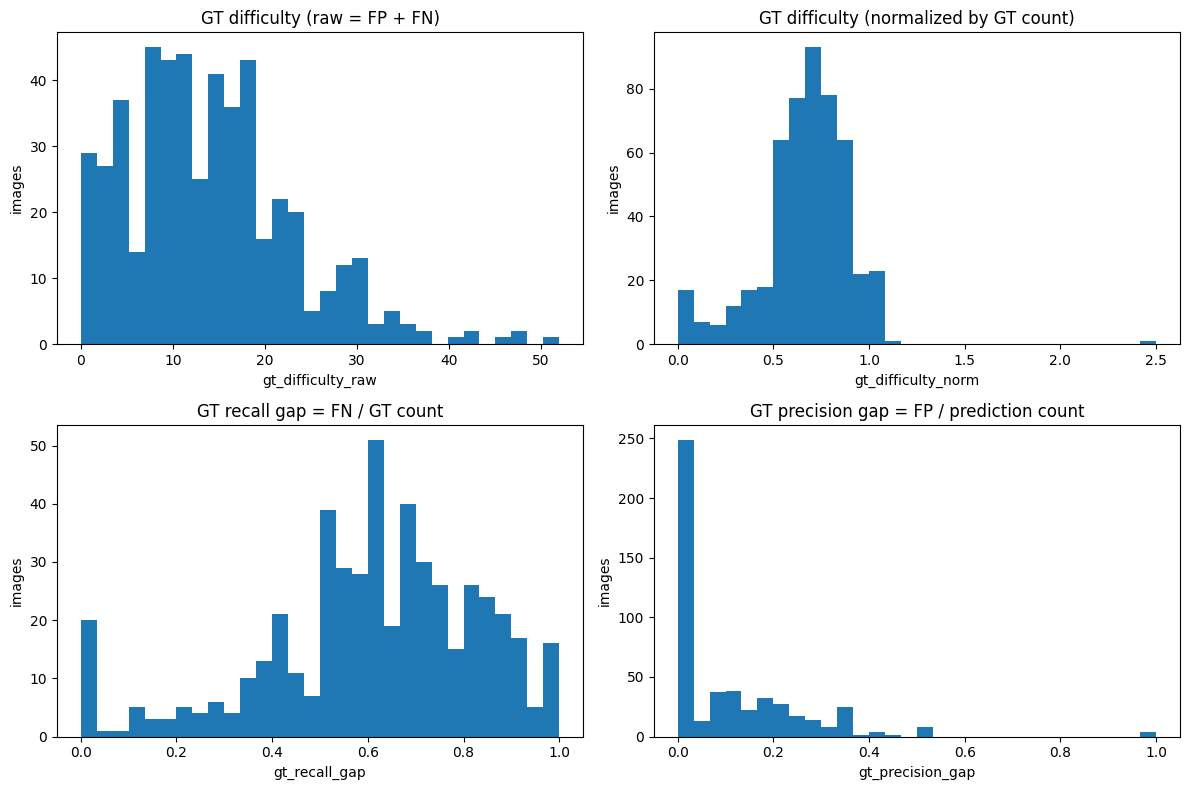

,count,mean,std,min,25%,50%,75%,max
gt_gt_object_count,500.0,20.360000,11.380925,0.0,12.00000,19.000000,28.000000,66.0
gt_prediction_count,500.0,8.408000,5.980725,0.0,4.00000,7.000000,12.000000,32.0
gt_false_positive_count,500.0,1.040000,1.548935,0.0,0.00000,1.000000,1.000000,9.0
gt_false_negative_count,500.0,12.992000,8.708134,0.0,7.00000,12.000000,18.000000,50.0
gt_difficulty_raw,500.0,14.032000,9.100143,0.0,8.00000,13.000000,19.000000,52.0
gt_difficulty_norm,500.0,0.663398,0.237131,0.0,0.56698,0.685213,0.813079,2.5
gt_recall_gap,500.0,0.606714,0.227893,0.0,0.50000,0.625000,0.764706,1.0
gt_precision_gap,500.0,0.103701,0.147033,0.0,0.00000,0.051587,0.166667,1.0


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_specs = [
    ("gt_difficulty_raw", "GT difficulty (raw = FP + FN)"),
    ("gt_difficulty_norm", "GT difficulty (normalized by GT count)"),
    ("gt_recall_gap", "GT recall gap = FN / GT count"),
    ("gt_precision_gap", "GT precision gap = FP / prediction count"),
]
for ax, (column_name, title) in zip(axes.flat, plot_specs):
    ax.hist(per_image_analysis_df[column_name], bins=30)
    ax.set_title(title)
    ax.set_xlabel(column_name)
    ax.set_ylabel("images")
plt.tight_layout()
plt.show()

per_image_analysis_df[
    [
        "gt_gt_object_count",
        "gt_prediction_count",
        "gt_false_positive_count",
        "gt_false_negative_count",
        "gt_difficulty_raw",
        "gt_difficulty_norm",
        "gt_recall_gap",
        "gt_precision_gap",
    ]
].describe().T


## 7. Proxy score distributions

Before correlating anything, it helps to look at the marginal distributions of the main proxy families.

One small convention change used below:
- `proxy_mean_score` is converted into `proxy_low_mean_score = 1 - mean_score`
- this makes larger values consistently mean "harder image" for most proxies


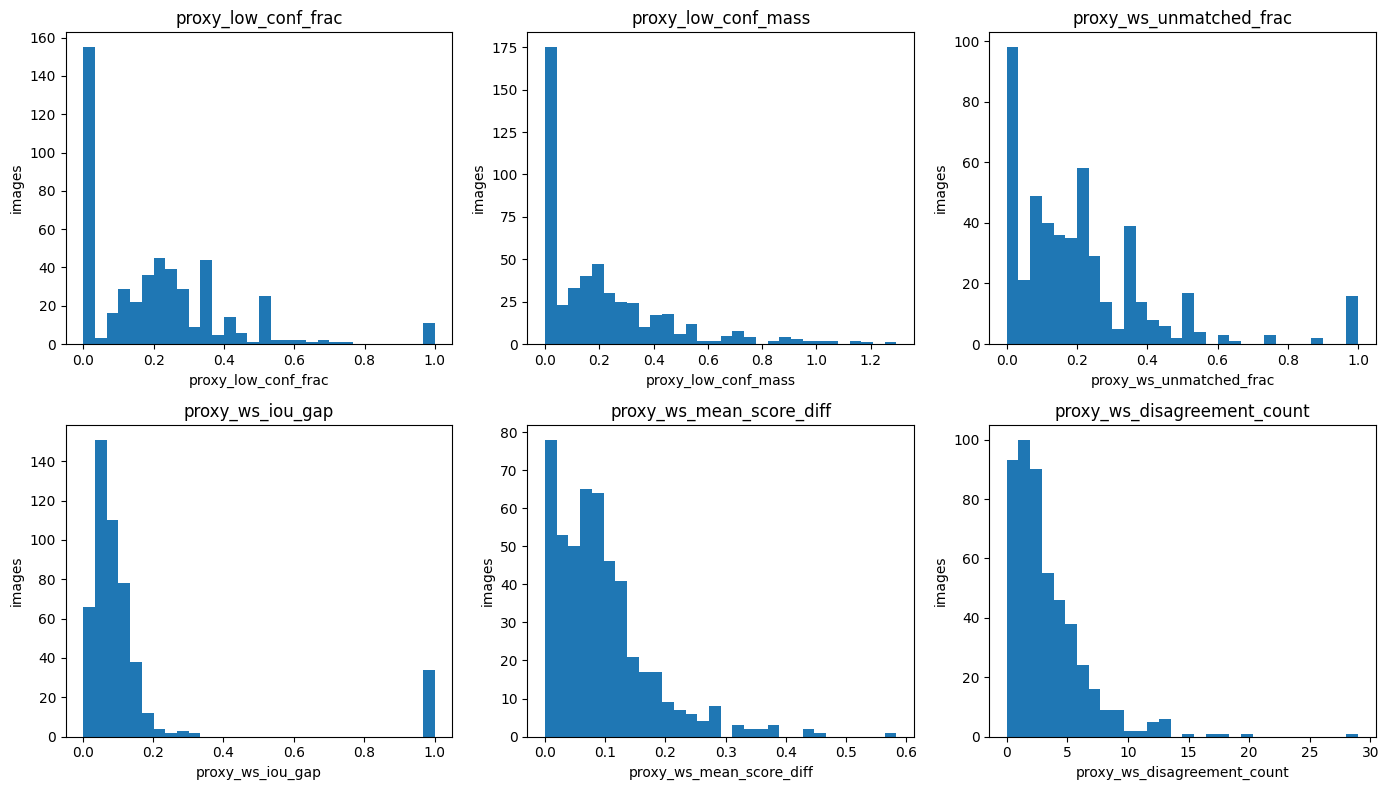

In [6]:
per_image_analysis_df["proxy_low_mean_score"] = 1.0 - per_image_analysis_df["proxy_mean_score"]

candidate_proxy_columns = [
    "proxy_pred_count",
    "proxy_low_mean_score",
    "proxy_score_std",
    "proxy_low_conf_count",
    "proxy_low_conf_frac",
    "proxy_low_conf_mass",
    "proxy_ws_unmatched_count",
    "proxy_ws_unmatched_frac",
    "proxy_ws_iou_gap",
    "proxy_ws_mean_score_diff",
    "proxy_ws_class_disagree_count",
    "proxy_ws_class_disagree_frac",
    "proxy_ws_disagreement_count",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
proxy_distribution_columns = [
    "proxy_low_conf_frac",
    "proxy_low_conf_mass",
    "proxy_ws_unmatched_frac",
    "proxy_ws_iou_gap",
    "proxy_ws_mean_score_diff",
    "proxy_ws_disagreement_count",
]
for ax, column_name in zip(axes.flat, proxy_distribution_columns):
    ax.hist(per_image_analysis_df[column_name], bins=30)
    ax.set_title(column_name)
    ax.set_xlabel(column_name)
    ax.set_ylabel("images")
plt.tight_layout()
plt.show()


## 8. Correlation of single proxies with GT difficulty

This is the core quantitative comparison.

For each no-GT proxy, we compute SROCC against several GT-derived targets:
- `gt_difficulty_raw`
- `gt_difficulty_norm`
- `gt_false_negative_count`
- `gt_false_positive_count`
- `gt_recall_gap`
- `gt_precision_gap`

The most important target for this notebook is usually `gt_difficulty_norm`, because it discounts image crowdedness.


In [7]:
single_proxy_correlation_rows = []
for proxy_name in candidate_proxy_columns:
    single_proxy_correlation_rows.append(
        {
            "proxy": proxy_name,
            "srocc_gt_raw": spearman_rank_corr(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_difficulty_raw"]),
            "srocc_gt_norm": spearman_rank_corr(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_difficulty_norm"]),
            "srocc_fn": spearman_rank_corr(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_false_negative_count"]),
            "srocc_fp": spearman_rank_corr(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_false_positive_count"]),
            "srocc_recall_gap": spearman_rank_corr(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_recall_gap"]),
            "srocc_precision_gap": spearman_rank_corr(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_precision_gap"]),
        }
    )

single_proxy_correlation_df = pd.DataFrame(single_proxy_correlation_rows).sort_values(
    "srocc_gt_norm",
    ascending=False,
)
single_proxy_correlation_df


,proxy,srocc_gt_raw,srocc_gt_norm,srocc_fn,srocc_fp,srocc_recall_gap,srocc_precision_gap
1,proxy_low_mean_score,0.096499,0.230077,0.048976,0.300053,0.086563,0.339013
8,proxy_ws_iou_gap,0.152089,0.118905,0.118801,0.196736,0.054660,0.138138
7,proxy_ws_unmatched_frac,0.192576,0.103295,0.164272,0.206003,0.037461,0.219195
4,proxy_low_conf_frac,0.280557,0.058000,0.223450,0.445797,-0.042926,0.443096
11,proxy_ws_class_disagree_frac,0.124251,0.051970,0.077380,0.241569,-0.044676,0.215614
10,proxy_ws_class_disagree_count,0.130330,0.046494,0.080906,0.252504,-0.053297,0.221483
9,proxy_ws_mean_score_diff,0.192650,-0.043599,0.162992,0.218481,-0.076370,0.169669
5,proxy_low_conf_mass,0.376987,-0.131326,0.282561,0.657078,-0.268613,0.528896
2,proxy_score_std,0.287886,-0.131422,0.228293,0.461599,-0.209582,0.411606
3,proxy_low_conf_count,0.420516,-0.143271,0.326258,0.654228,-0.269757,0.513746


## 9. Weak/strong agreement diagnostics

These plots are not GT targets. They help interpret the disagreement-based proxy family directly.

They answer questions like:
- when weak and strong do match, how consistent are their boxes?
- how different are their confidence scores?
- how often does the predicted class stay the same?


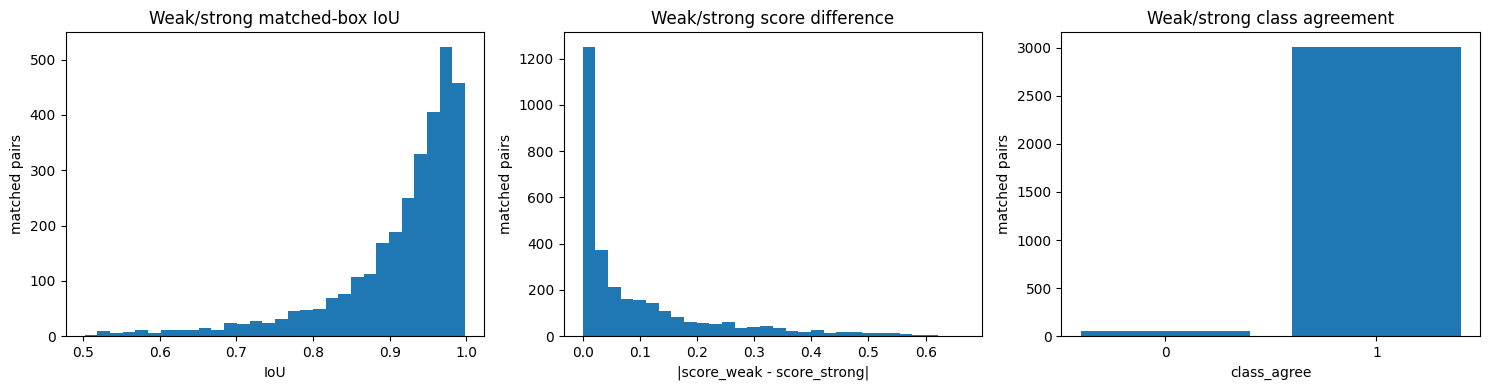

In [8]:
if len(weak_strong_match_df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(weak_strong_match_df["iou"], bins=30)
    axes[0].set_title("Weak/strong matched-box IoU")
    axes[0].set_xlabel("IoU")
    axes[0].set_ylabel("matched pairs")

    axes[1].hist(weak_strong_match_df["score_diff"], bins=30)
    axes[1].set_title("Weak/strong score difference")
    axes[1].set_xlabel("|score_weak - score_strong|")
    axes[1].set_ylabel("matched pairs")

    axes[2].hist(weak_strong_match_df["class_agree"], bins=[-0.5, 0.5, 1.5], rwidth=0.8)
    axes[2].set_xticks([0, 1])
    axes[2].set_title("Weak/strong class agreement")
    axes[2].set_xlabel("class_agree")
    axes[2].set_ylabel("matched pairs")
    plt.tight_layout()
    plt.show()

    pd.DataFrame(
        {
            "mean_matched_iou": [weak_strong_match_df["iou"].mean()],
            "mean_score_diff": [weak_strong_match_df["score_diff"].mean()],
            "class_agreement_rate": [weak_strong_match_df["class_agree"].mean()],
            "num_matches": [len(weak_strong_match_df)],
        }
    )
else:
    print("No weak/strong matches were found at the current thresholds.")


## 10. Scatter plots for the strongest single proxies

To keep the notebook compact, we only plot the top few single proxies ranked by SROCC with normalized GT difficulty.

These plots help answer whether a strong rank correlation is visually sensible or driven by a few outliers.


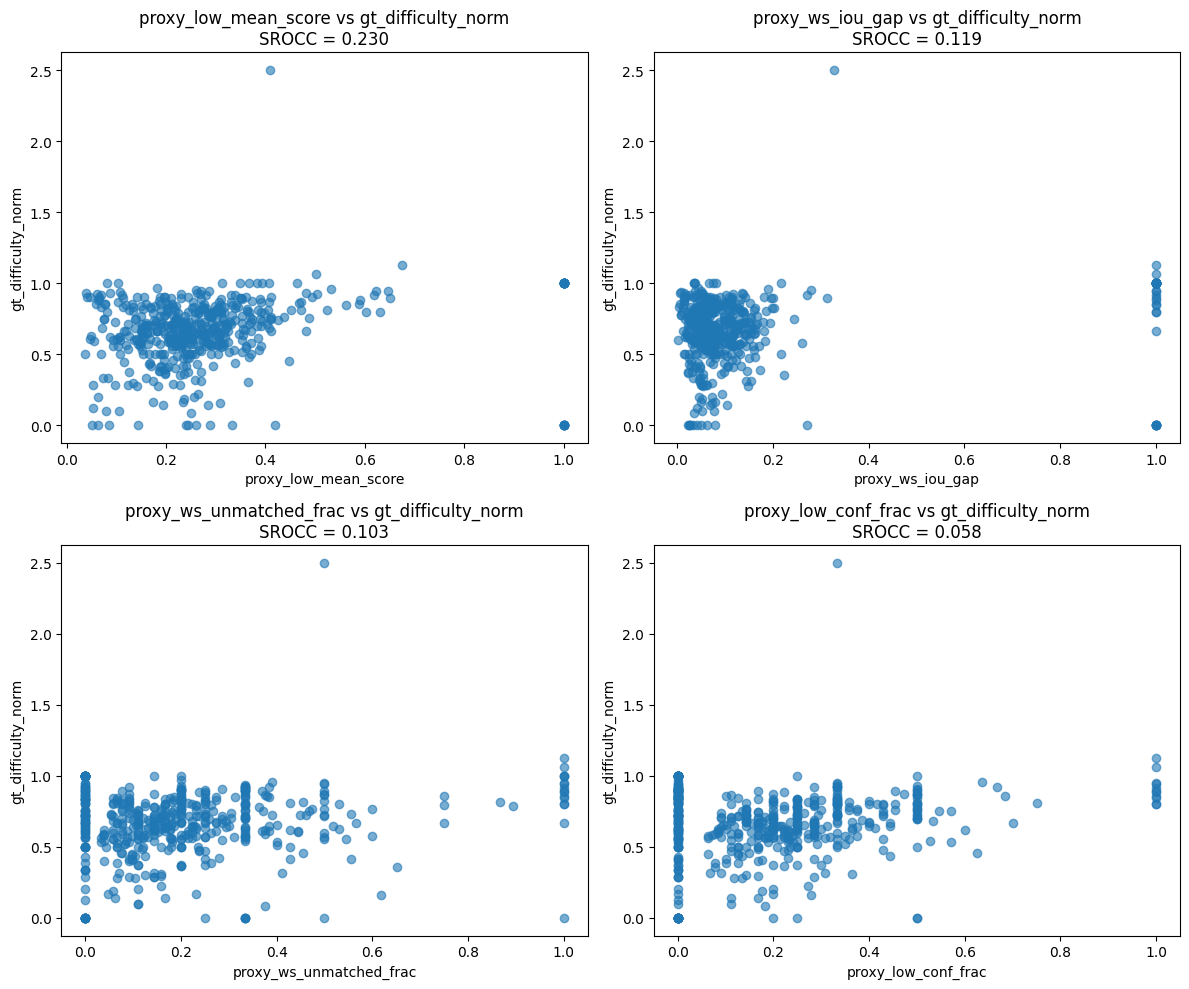

In [9]:
top_single_proxy_names = single_proxy_correlation_df.head(NUM_SCATTER_PLOTS)["proxy"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, proxy_name in zip(axes.flat, top_single_proxy_names):
    ax.scatter(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_difficulty_norm"], alpha=0.6)
    ax.set_xlabel(proxy_name)
    ax.set_ylabel("gt_difficulty_norm")
    srocc_value = single_proxy_correlation_df.loc[
        single_proxy_correlation_df["proxy"] == proxy_name,
        "srocc_gt_norm",
    ].iloc[0]
    ax.set_title(f"{proxy_name} vs gt_difficulty_norm\nSROCC = {srocc_value:.3f}")
plt.tight_layout()
plt.show()


## 11. Simple proxy combinations

We now try a few small, interpretable combinations.
Each combination is an average of z-scored components so that no raw feature dominates purely because of numeric scale.

The combinations below are deliberately simple:
- `proxy_combo_confidence`: only confidence-based instability
- `proxy_combo_view_disagreement`: only weak/strong disagreement
- `proxy_combo_hybrid`: one small mixed combination from both families


In [10]:
per_image_analysis_df["proxy_combo_confidence"] = (
    zscore(per_image_analysis_df["proxy_low_conf_frac"])
    + zscore(per_image_analysis_df["proxy_low_conf_mass"])
    + zscore(per_image_analysis_df["proxy_low_mean_score"])
) / 3.0

per_image_analysis_df["proxy_combo_view_disagreement"] = (
    zscore(per_image_analysis_df["proxy_ws_unmatched_frac"])
    + zscore(per_image_analysis_df["proxy_ws_iou_gap"])
    + zscore(per_image_analysis_df["proxy_ws_mean_score_diff"])
    + zscore(per_image_analysis_df["proxy_ws_class_disagree_frac"])
) / 4.0

per_image_analysis_df["proxy_combo_hybrid"] = (
    zscore(per_image_analysis_df["proxy_low_conf_mass"])
    + zscore(per_image_analysis_df["proxy_low_conf_frac"])
    + zscore(per_image_analysis_df["proxy_ws_unmatched_frac"])
    + zscore(per_image_analysis_df["proxy_ws_iou_gap"])
    + zscore(per_image_analysis_df["proxy_ws_mean_score_diff"])
) / 5.0

combined_proxy_columns = [
    "proxy_combo_confidence",
    "proxy_combo_view_disagreement",
    "proxy_combo_hybrid",
]

combined_proxy_correlation_rows = []
for proxy_name in combined_proxy_columns:
    combined_proxy_correlation_rows.append(
        {
            "proxy": proxy_name,
            "srocc_gt_raw": spearman_rank_corr(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_difficulty_raw"]),
            "srocc_gt_norm": spearman_rank_corr(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_difficulty_norm"]),
            "srocc_fn": spearman_rank_corr(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_false_negative_count"]),
            "srocc_fp": spearman_rank_corr(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_false_positive_count"]),
            "srocc_recall_gap": spearman_rank_corr(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_recall_gap"]),
            "srocc_precision_gap": spearman_rank_corr(per_image_analysis_df[proxy_name], per_image_analysis_df["gt_precision_gap"]),
        }
    )

combined_proxy_correlation_df = pd.DataFrame(combined_proxy_correlation_rows).sort_values(
    "srocc_gt_norm",
    ascending=False,
)
combined_proxy_correlation_df


,proxy,srocc_gt_raw,srocc_gt_norm,srocc_fn,srocc_fp,srocc_recall_gap,srocc_precision_gap
1,proxy_combo_view_disagreement,0.075971,0.186803,0.042047,0.175267,0.094930,0.183916
2,proxy_combo_hybrid,0.242786,0.118678,0.173222,0.441081,-0.018052,0.401616
0,proxy_combo_confidence,0.213288,0.095719,0.140417,0.466717,-0.043163,0.427896


## 12. Summary correlation table

This table puts the strongest single proxies and the simple combined proxies together so we can compare them directly.

This is usually the most useful table to keep in mind for the next method-design step.


In [11]:
top_single_proxy_summary_df = single_proxy_correlation_df.head(8).copy()
summary_correlation_df = pd.concat(
    [top_single_proxy_summary_df, combined_proxy_correlation_df],
    ignore_index=True,
).sort_values("srocc_gt_norm", ascending=False)
summary_correlation_df


,proxy,srocc_gt_raw,srocc_gt_norm,srocc_fn,srocc_fp,srocc_recall_gap,srocc_precision_gap
0,proxy_low_mean_score,0.096499,0.230077,0.048976,0.300053,0.086563,0.339013
8,proxy_combo_view_disagreement,0.075971,0.186803,0.042047,0.175267,0.094930,0.183916
1,proxy_ws_iou_gap,0.152089,0.118905,0.118801,0.196736,0.054660,0.138138
9,proxy_combo_hybrid,0.242786,0.118678,0.173222,0.441081,-0.018052,0.401616
2,proxy_ws_unmatched_frac,0.192576,0.103295,0.164272,0.206003,0.037461,0.219195
10,proxy_combo_confidence,0.213288,0.095719,0.140417,0.466717,-0.043163,0.427896
3,proxy_low_conf_frac,0.280557,0.058000,0.223450,0.445797,-0.042926,0.443096
4,proxy_ws_class_disagree_frac,0.124251,0.051970,0.077380,0.241569,-0.044676,0.215614
5,proxy_ws_class_disagree_count,0.130330,0.046494,0.080906,0.252504,-0.053297,0.221483
6,proxy_ws_mean_score_diff,0.192650,-0.043599,0.162992,0.218481,-0.076370,0.169669


## 13. Qualitative interpretation on the hardest images

A strong numeric correlation is more convincing if the hardest GT-ranked images also look genuinely difficult.

Here we rank images by normalized GT difficulty and visualize:
- GT boxes in green
- original-view predictions in red

This is only a qualitative sanity check. It helps us understand what the proxy scores are reacting to.


In [12]:
hardest_images_df = per_image_analysis_df.sort_values(
    "gt_difficulty_norm",
    ascending=False,
).head(NUM_HARDEST_EXAMPLES)

hardest_images_df[
    [
        "sample_id",
        "gt_gt_object_count",
        "gt_prediction_count",
        "gt_false_positive_count",
        "gt_false_negative_count",
        "gt_difficulty_raw",
        "gt_difficulty_norm",
        "proxy_combo_hybrid",
    ]
]


,sample_id,gt_gt_object_count,gt_prediction_count,gt_false_positive_count,gt_false_negative_count,gt_difficulty_raw,gt_difficulty_norm,proxy_combo_hybrid
298,target_val:lindau:lindau_000031_000019:beta=0.02,2.0,3.0,3.0,2.0,5.0,2.5000,0.379812
103,target_val:frankfurt:frankfurt_000001_019698:b...,8.0,1.0,1.0,8.0,9.0,1.1250,1.997312
152,target_val:frankfurt:frankfurt_000001_042098:b...,16.0,1.0,1.0,16.0,17.0,1.0625,1.853929
284,target_val:lindau:lindau_000017_000019:beta=0.02,0.0,1.0,1.0,0.0,1.0,1.0000,0.869116


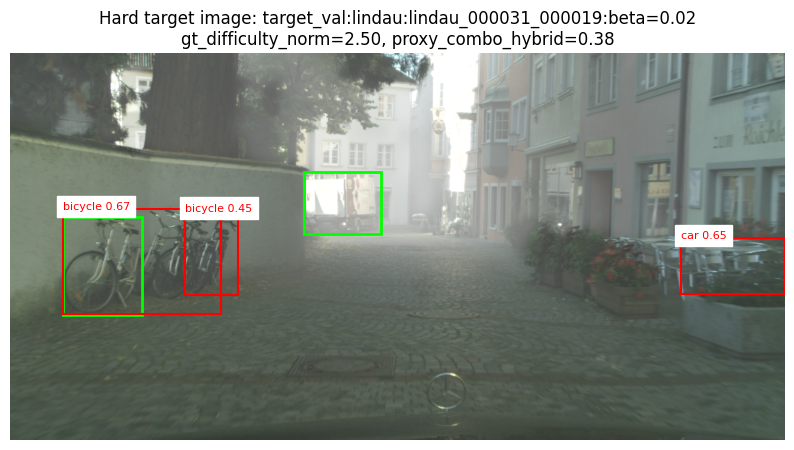

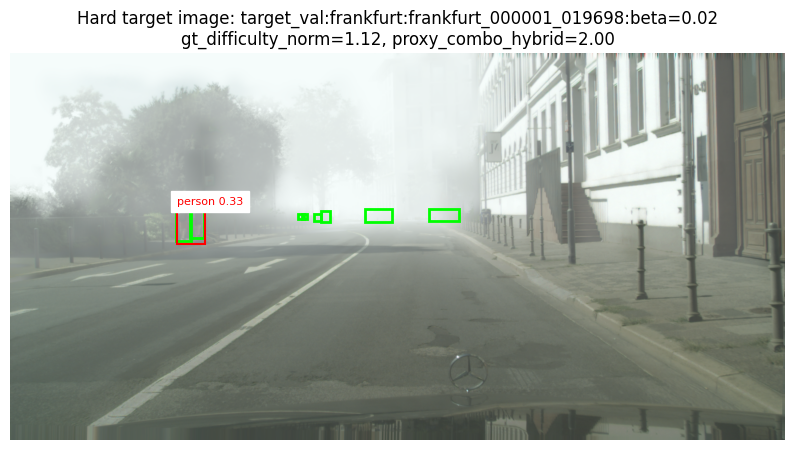

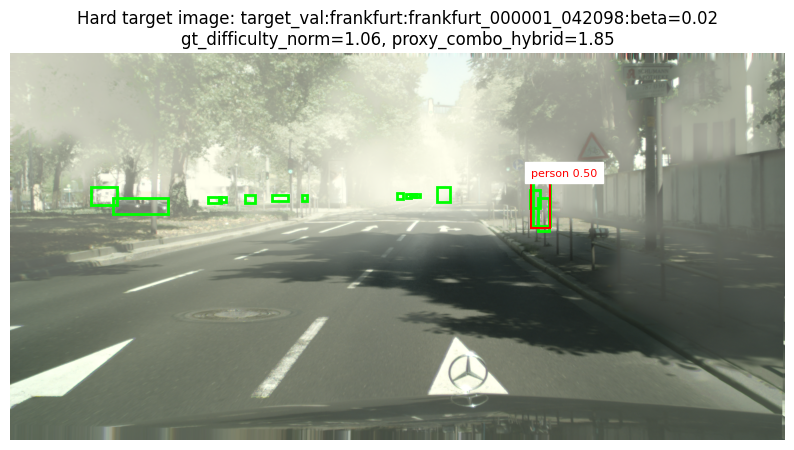

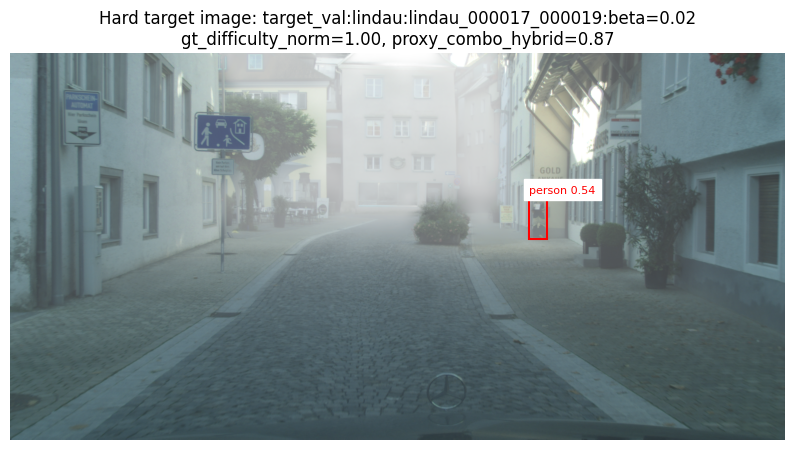

In [13]:
for _, sample_row in hardest_images_df.iterrows():
    show_gt_and_original_predictions(sample_row, image_cache, title_prefix="Hard target image: ")


## 14. Final summary

This cell gives a compact end-of-notebook summary:
- which GT difficulty definitions were used
- which no-GT proxy families were evaluated
- which single proxy and which combined proxy achieved the best SROCC with normalized GT difficulty


In [14]:
best_single_proxy_row = single_proxy_correlation_df.iloc[0]
best_combined_proxy_row = combined_proxy_correlation_df.iloc[0]

final_summary_df = pd.DataFrame(
    [
        {
            "summary_item": "GT difficulty definitions",
            "value": "gt_difficulty_raw = FP + FN; gt_difficulty_norm = (FP + FN) / GT count; gt_recall_gap = FN / GT count; gt_precision_gap = FP / prediction count",
        },
        {
            "summary_item": "No-GT proxy families",
            "value": "confidence-based proxies and weak/strong disagreement-based proxies",
        },
        {
            "summary_item": "Best single proxy by SROCC(gt_difficulty_norm)",
            "value": f"{best_single_proxy_row['proxy']} (SROCC = {best_single_proxy_row['srocc_gt_norm']:.3f})",
        },
        {
            "summary_item": "Best simple proxy combination by SROCC(gt_difficulty_norm)",
            "value": f"{best_combined_proxy_row['proxy']} (SROCC = {best_combined_proxy_row['srocc_gt_norm']:.3f})",
        },
    ]
)
final_summary_df


,summary_item,value
0,GT difficulty definitions,gt_difficulty_raw = FP + FN; gt_difficulty_nor...
1,No-GT proxy families,confidence-based proxies and weak/strong disag...
2,Best single proxy by SROCC(gt_difficulty_norm),proxy_low_mean_score (SROCC = 0.230)
3,Best simple proxy combination by SROCC(gt_diff...,proxy_combo_view_disagreement (SROCC = 0.187)
